In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D, GRU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('dataset_reviews.csv')
print("Jumlah data awal:", len(df))
df.head()

Jumlah data awal: 10500


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\atha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,score
0,ko fitur dana instan nya belom timbul.padahal ...,5
1,sangat cocok untuk menyimpan uang,5
2,sekarang sering gangguan,3
3,👌👌,2
4,karena ingin mengirim sesama bank tidak membayar,5


In [13]:
def label_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

df['sentiment'] = df['score'].apply(label_sentiment)

indonesian_stopwords = set(stopwords.words('indonesian'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()                                  
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)    
    text = re.sub(r'[^\w\s]', '', text)                    
    text = re.sub(r'\d+', '', text)                        
    tokens = text.split()
    tokens = [w for w in tokens if w not in indonesian_stopwords and len(w) > 2] # Stopword removal
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df = df.dropna(subset=['clean_text']).drop_duplicates(subset=['clean_text'])
df = df[df['clean_text'].str.strip() != '']

print("Jumlah data bersih:", len(df))
print(df['sentiment'].value_counts())

Jumlah data bersih: 5935
sentiment
positif    3461
negatif    2117
netral      357
Name: count, dtype: int64


In [17]:
Y = pd.get_dummies(df['sentiment']).values
Y_labels = np.argmax(Y, axis=1) 
MAX_NUM_WORDS = 2500 
MAX_SEQUENCE_LENGTH = 100

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

X_tfidf = tokenizer.texts_to_matrix(df['clean_text'], mode='tfidf')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

callbacks_es = [EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)]

X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X_tfidf, Y, test_size=0.2, random_state=42)

model1 = Sequential([
    Input(shape=(MAX_NUM_WORDS,)), 
    Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.6), 
    Dense(3, activation='softmax')
])
model1.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

print("=== Training Skema 1 (Deep Learning Regularized) ===")
history1 = model1.fit(X_train1, Y_train1, epochs=15, batch_size=64, 
                      validation_data=(X_test1, Y_test1), callbacks=callbacks_es, verbose=1)

acc1 = model1.evaluate(X_test1, Y_test1, verbose=0)[1]
print(f"-> Akurasi Testing Skema 1 (DL): {acc1 * 100:.2f}%\n")

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_tfidf, Y_labels, test_size=0.2, random_state=123)

print("=== Training Skema 2 (Logistic Regression) ===")
model2 = LogisticRegression(max_iter=1000, C=1.0)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
acc2 = accuracy_score(y_test2, y_pred2)
print(f"-> Akurasi Testing Skema 2 (LogReg): {acc2 * 100:.2f}%\n")

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_tfidf, Y_labels, test_size=0.3, random_state=999)

print("=== Training Skema 3 (Random Forest) ===")
model3 = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)
acc3 = accuracy_score(y_test3, y_pred3)
print(f"-> Akurasi Testing Skema 3 (Random Forest): {acc3 * 100:.2f}%\n")

=== Training Skema 1 (Deep Learning Regularized) ===
Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5864 - loss: 1.0563 - val_accuracy: 0.7498 - val_loss: 0.8131
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7207 - loss: 0.8022 - val_accuracy: 0.7725 - val_loss: 0.7045
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7570 - loss: 0.7095 - val_accuracy: 0.7776 - val_loss: 0.6660
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7839 - loss: 0.6568 - val_accuracy: 0.7902 - val_loss: 0.6525
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7854 - loss: 0.6393 - val_accuracy: 0.7860 - val_loss: 0.6519
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7980 - loss: 0.6040 - val_accuracy: 0.7877 - val_loss: 0.6508
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8056 - loss: 0.5961 - val_accuracy: 0.7911 - val_loss: 0.6520
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report (Model Terbaik) ---
              precision    recall  f1-score   support

     negatif       0.74      0.77      0.75       423
      netral       0.00      0.00      0.00        72
     positif       0.81      0.87      0.84       692

    accuracy                           0.78      1187
   macro avg       0.52      0.55      0.53      1187
weighted avg       0.73      0.78      0.76      1187



c:\Users\atha\miniconda3\envs\dicoding-nlp\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\atha\miniconda3\envs\dicoding-nlp\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\atha\miniconda3\envs\dicoding-nlp\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

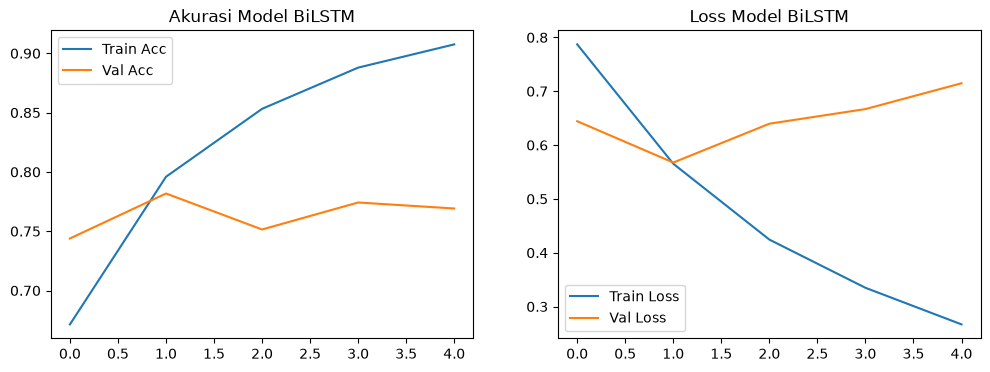

In [ ]:
y_pred = model1.predict(X_test1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(Y_test1, axis=1)

labels_map = ['negatif', 'netral', 'positif']

print("\n--- Classification Report (Model Terbaik) ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=labels_map))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Train Acc')
plt.plot(history1.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi Model BiLSTM')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.title('Loss Model BiLSTM')
plt.legend()
plt.show()

In [ ]:
def predict_sentiment_text(text_input, model, tokenizer):
    cleaned = clean_text(text_input)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    pred = model.predict(padded, verbose=0)
    class_idx = np.argmax(pred, axis=1)[0]
    confidence = pred[0][class_idx] * 100
    
    classes = ['Negatif', 'Netral', 'Positif']
    return classes[class_idx], confidence

sample_reviews = [
    "Aplikasi ini sangat bagus dan cepat saat transaksi! Transaksi sukses tanpa hambatan.",
    "Fiturnya lumayan, tapi kadang loading-nya sedikit lama saat jam sibuk.",
    "Sangat mengecewakan! Saldo saya berkurang tapi transaksi gagal, mana customer service lambat balurnya!"
]

print("HASIL PENGUJIAN INFERENSI MODUL SENTIMEN:")
print("-" * 65)
for text in sample_reviews:
    label, conf = predict_sentiment_text(text, model1, tokenizer)
    print(f"Teks Input  : \"{text}\"")
    print(f"Hasil Kelas : [{label.upper()}] (Tingkat Keyakinan: {conf:.2f}%)")
    print("-" * 65)

HASIL PENGUJIAN INFERENSI MODUL SENTIMEN:
-----------------------------------------------------------------
Teks Input  : "Aplikasi ini sangat bagus dan cepat saat transaksi! Transaksi sukses tanpa hambatan."
Hasil Kelas : [POSITIF] (Tingkat Keyakinan: 98.28%)
-----------------------------------------------------------------
Teks Input  : "Fiturnya lumayan, tapi kadang loading-nya sedikit lama saat jam sibuk."
Hasil Kelas : [POSITIF] (Tingkat Keyakinan: 89.80%)
-----------------------------------------------------------------
Teks Input  : "Sangat mengecewakan! Saldo saya berkurang tapi transaksi gagal, mana customer service lambat balurnya!"
Hasil Kelas : [NEGATIF] (Tingkat Keyakinan: 96.85%)
-----------------------------------------------------------------
